# Exploration stochastique FR

## 1. Imports

In [2]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.lines import Line2D
from pathlib import Path
import geopandas as gpd

# If the project was cloned from GitHub, replace ".." with "../../src" below.
# If morta_nuts2 is installed as a package (e.g. via pip/uv), keep ".." as is.
sys.path.append(os.path.abspath("../../src"))

from morta_nuts2.data.eurostat import *
from morta_nuts2.data.mortality_table import *
from morta_nuts2.model.Bsplines.Bsplines import make_bspline_basis
from morta_nuts2.model.parameters_init.param_init import *
from morta_nuts2.model.projection.project_class import *
from morta_nuts2.model.LC_p.lcp_class import *
from morta_nuts2.model.LL_p.llp_class import *
from morta_nuts2.graph.plot_class import *

## 2. Data Loading

In [3]:
# By default, downloaded data is stored in the same directory as the script.
# Use EurostatConfig.set_default_data_path() to redirect storage to a custom path.
# ── Change the path below to match your local setup ──────────────────────────

EurostatConfig.set_default_data_path("C:/Users/Thomas Hames/Documents/GitHub/morta_nuts2/data")

data_brute    = Eurostat_data()
mortality_fr  = data_brute.load("mortality",  "FR")
deaths_fr     = data_brute.load("deaths",     "FR")
population_fr = data_brute.load("population", "FR")


⚠️  [Eurostat] DATA QUALITY WARNING
   Eurostat datasets may contain anomalies such as missing values,
   suppressed cells, inconsistent time series, or regional boundary
   changes. It is strongly recommended to perform thorough data
   quality checks before proceeding with any analysis.

📂 Loading NUTS shapefile... NUTS_RG_01M_2024_3035.shp
✅ Shapefile loaded (1798 features)
💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


## 3. Data Preparation

In [4]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr, population_fr, deaths_fr, gender="T")
table = table[table['year'] != 2024]  # exclude incomplete year

2026-04-15 18:42:17,882 - MortalityCalculator - INFO - Loading shapefile: c:\Users\Thomas Hames\Documents\GitHub\morta_nuts2\src\morta_nuts2\NUTS_files\NUTS_RG_01M_2024_3035.shp
2026-04-15 18:42:18,004 - MortalityCalculator - INFO - 1793 regions loaded
2026-04-15 18:42:18,017 - MortalityCalculator - INFO - MortalityCalculator initialized with 1793 regions
2026-04-15 18:42:18,017 - MortalityCalculator - INFO - Validating input data...
2026-04-15 18:42:19,534 - MortalityCalculator - INFO - Validation successful
2026-04-15 18:42:19,534 - root - INFO - validate_input_data executed in 1.52 seconds
2026-04-15 18:42:19,551 - MortalityCalculator - INFO - Result retrieved from cache
2026-04-15 18:42:19,551 - root - INFO - calculate_mortality executed in 1.53 seconds


In [5]:
Muxtg, Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg  :", Dxtg.shape)
print("Shape Extg  :", Extg.shape)
print("Shape Muxtg :", Muxtg.shape)
print("Ages   :", len(xv))
print("Years  :", len(tv))
print("Regions:", len(regions))

nb_regions = len(regions)
nb_years   = len(tv)

# B-spline hyperparameters
degree  = 3
n_knots = 25
lam     = 0
nb_iter = 5000

# Aggregate national exposure and deaths
Dxt = np.sum(Dxtg, axis=2)
Ext = np.sum(Extg, axis=2)

# Output path
path_fr = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/output_note/FR"

# France NUTS2 region labels
France_nuts2 = {
    "FR10": "IDF",  "FRB0": "CVL",  "FRC1": "BOU",  "FRC2": "FCO",
    "FRD1": "BN",   "FRD2": "HN",   "FRE1": "NPC",  "FRE2": "PIC",
    "FRF1": "ALS",  "FRF2": "CHA",  "FRF3": "LOR",  "FRG0": "PDL",
    "FRH0": "BRE",  "FRI1": "AQU",  "FRI2": "LIM",  "FRI3": "POI",
    "FRJ1": "LR",   "FRJ2": "MPY",  "FRK1": "AUV",  "FRK2": "RA",
    "FRL0": "PACA", "FRM0": "COR",
}
France_nuts2_full = {
    "FR10": "Ile-de-France",           "FRB0": "Centre — Val de Loire",
    "FRC1": "Bourgogne",               "FRC2": "Franche-Comté",
    "FRD1": "Basse-Normandie",         "FRD2": "Haute-Normandie",
    "FRE1": "Nord-Pas de Calais",      "FRE2": "Picardie",
    "FRF1": "Alsace",                  "FRF2": "Champagne-Ardenne",
    "FRF3": "Lorraine",                "FRG0": "Pays de la Loire",
    "FRH0": "Bretagne",                "FRI1": "Aquitaine",
    "FRI2": "Limousin",                "FRI3": "Poitou-Charentes",
    "FRJ1": "Languedoc-Roussillon",    "FRJ2": "Midi-Pyrénées",
    "FRK1": "Auvergne",                "FRK2": "Rhône-Alpes",
    "FRL0": "Provence-Alpes-Côte d'Azur", "FRM0": "Corse",
}
region_labels = [France_nuts2.get(r, r) for r in regions]

Shape Dxtg  : (83, 34, 22)
Shape Extg  : (83, 34, 22)
Shape Muxtg : (83, 34, 22)
Ages   : 83
Years  : 34
Regions: 22


## 4. Model Fitting

### 4.1 Lee-Carter Model

#### Non-Parametric Lee-Carter

In [6]:
# Initial values
ax_init    = -0.001 * np.zeros_like(xv)
bx_init    =  0.001 * np.ones_like(xv)
kappa_init =          np.ones(len(tv))

model_lc_classic = LeeCarter.Classic(nb_iter=nb_iter, eta=1)

results_lc_classic = model_lc_classic.fit(
    ax    = ax_init,
    bx    = bx_init,
    kappa = kappa_init,
    Extg  = Extg,
    Dxtg  = Dxtg,
    xv    = xv,
    tv    = tv,
)

results_lc_classic['fit_statistics']

,N,m,degree,dofs,lnL,AIC,BIC
0,62084,NA,NA,200,-282530.49,565460.97,567268.22


#### Parametric Lee-Carter

In [7]:
_, _, n_basis = make_bspline_basis(xv, degree, n_knots)

ax_coef_init, bx_coef_init, kappa_init = lcp_parametrique_init_national(
    Dxtg, Extg, xv, tv, n_basis=n_basis, degree=degree, n_knots=n_knots
)

model_lcp_nat = LeeCarter.Parametric.National(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=nb_iter,
    eta0=0.2,
    tol=1e-4,
    verbose=False,
)

results_lcp_nat = model_lcp_nat.fit(
    ax_coef_init = ax_coef_init,
    bx_coef_init = bx_coef_init,
    kappa_init   = kappa_init,
    Extg         = Extg,
    Dxtg         = Dxtg,
    xv           = xv,
    tv           = tv,
)
results_lcp_nat['fit_statistics']

,N,n_basis,dofs,lnL,deviance,AIC,BIC
0,62084,27,88.0,-282989.13,-1.103963e+08,566154.26,566949.45


### 4.2 Li and Lee Model

#### Non-Parametric Li and Lee

In [8]:
# Regional initial values
bx_gr_init    = 1e-6 * np.ones((len(xv), len(regions)))
kappa_gr_init = 1e-6 * np.ones((len(tv), len(regions)))

model_ll_classic = LiLee.Classic(nb_iter=nb_iter, verbose=False)

result_ll = model_ll_classic.fit(
    ax       = ax_init,
    bx       = bx_init,
    bx_gr    = bx_gr_init,
    kappa    = kappa_init,
    kappa_gr = kappa_gr_init,
    Extg     = Extg,
    Dxtg     = Dxtg,
    Muxtg    = Muxtg,
    xv       = xv,
    tv       = tv,
)
result_ll['fit_statistics']

,N,m,degree,dofs,lnL,AIC,BIC
0,62084,NA,NA,2750,-215387.22,436274.44,461124.11


#### Parametric Li and Lee with B-Splines

In [9]:
model_llp = LiLee.Parametric.FullModel(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=nb_iter,
    eta0=0.2,
    tol=1e-3,
    verbose=False,
)

init       = model_llp.init_params(Dxtg, Extg, xv)
result_llp = model_llp.fit(*init, Extg, Dxtg, xv, tv)
result_llp['fit_statistics']

,N,dofs,lnL,deviance,AIC,BIC
0,62084,1952.0,-209899.18,-110542495.6,423702.35,441341.1


## 5. Model Comparison

### 5.1 AIC / BIC / Log-Likelihood

In [10]:
models = {
    "LC":                results_lc_classic,
    "LC parametric":     results_lcp_nat,
    "Li-Lee":            result_ll,
    "Li-Lee parametric": result_llp,
}

rows = []
for name, result in models.items():
    stats = result['fit_statistics'].iloc[0]
    rows.append({
        "Model": name,
        "N":    stats["N"],
        "dofs": stats["dofs"],
        "lnL":  stats["lnL"],
        "AIC":  stats["AIC"],
        "BIC":  stats["BIC"],
    })

comparison_table = pd.DataFrame(rows)
# comparison_table.to_csv(path_fr + "/models.csv", index=False)
comparison_table

,Model,N,dofs,lnL,AIC,BIC
0,LC,62084.0,200.0,-282530.49,565460.97,567268.22
1,LC parametric,62084.0,88.0,-282989.13,566154.26,566949.45
2,Li-Lee,62084.0,2750.0,-215387.22,436274.44,461124.11
3,Li-Lee parametric,62084.0,1952.0,-209899.18,423702.35,441341.10


### 5.2 MAE & WMAE

In [11]:
mae_ll  = compute_mae(Muxtg, result_ll['fitted_values']['mu'],       weights=Extg)
mae_llp = compute_mae(Muxtg, result_llp['fitted_values']['mu'],      weights=Extg)
mae_lcp = compute_mae(Muxtg, results_lcp_nat['fitted_values']['mu'], weights=Extg)

print(f"MAE  global — Li-Lee classic : {mae_ll['global']:.6f} | Li-Lee parametric : {mae_llp['global']:.6f}")
print(f"WMAE global — Li-Lee classic : {mae_ll['wmae_global']:.6f} | Li-Lee parametric : {mae_llp['wmae_global']:.6f}")

# WMAE by region
mae = {
    "Li-Lee":            mae_ll['wmae_by_region'],
    "Li-Lee parametric": mae_llp['wmae_by_region'],
    "LC parametric":     mae_lcp['wmae_by_region'],
}

df_wmae = pd.DataFrame(mae, index=region_labels)

# Relative differences (%)
df_final = df_wmae.copy()
df_final["LLp vs LL (%)"]  = (df_wmae["Li-Lee parametric"] - df_wmae["Li-Lee"])         / df_wmae["Li-Lee"]         * 100
df_final["LCp vs LL (%)"]  = (df_wmae["LC parametric"]     - df_wmae["Li-Lee"])         / df_wmae["Li-Lee"]         * 100
df_final["LLp vs LCp (%)"] = (df_wmae["Li-Lee parametric"] - df_wmae["LC parametric"])  / df_wmae["LC parametric"]  * 100

df_final[["LLp vs LL (%)", "LCp vs LL (%)", "LLp vs LCp (%)"]] = df_final[["LLp vs LL (%)", "LCp vs LL (%)", "LLp vs LCp (%)"]].round(2)
df_final[["Li-Lee", "Li-Lee parametric", "LC parametric"]] = (
    df_final[["Li-Lee", "Li-Lee parametric", "LC parametric"]] * 10000
).round() / 100000

nuts2_inv  = {v: k for k, v in France_nuts2.items()}
df_final   = df_final.reset_index().rename(columns={"index": "label"})
df_final.insert(0, "nuts2",  df_final["label"].map(nuts2_inv))
df_final.insert(1, "region", df_final["label"].map(nuts2_inv).map(France_nuts2_full))
# df_final.to_csv(path_fr + "/wmae.csv", index=False)
df_final.head()

MAE  global — Li-Lee classic : 0.000459 | Li-Lee parametric : 0.000429
WMAE global — Li-Lee classic : 0.000294 | Li-Lee parametric : 0.000266


,nuts2,region,label,Li-Lee,Li-Lee parametric,LC parametric,LLp vs LL (%),LCp vs LL (%),LLp vs LCp (%)
0,FR10,Ile-de-France,IDF,0.00002,0.00002,0.00004,-22.63,100.55,-61.42
1,FRB0,Centre — Val de Loire,CVL,0.00003,0.00003,0.00004,-5.39,22.32,-22.65
2,FRC1,Bourgogne,BOU,0.00004,0.00004,0.00004,-3.68,15.05,-16.28
3,FRC2,Franche-Comté,FCO,0.00004,0.00004,0.00004,-4.50,5.96,-9.87
4,FRD1,Basse-Normandie,BN,0.00004,0.00004,0.00005,-7.64,12.56,-17.95


### 5.3 WMAE Bar Chart by Region

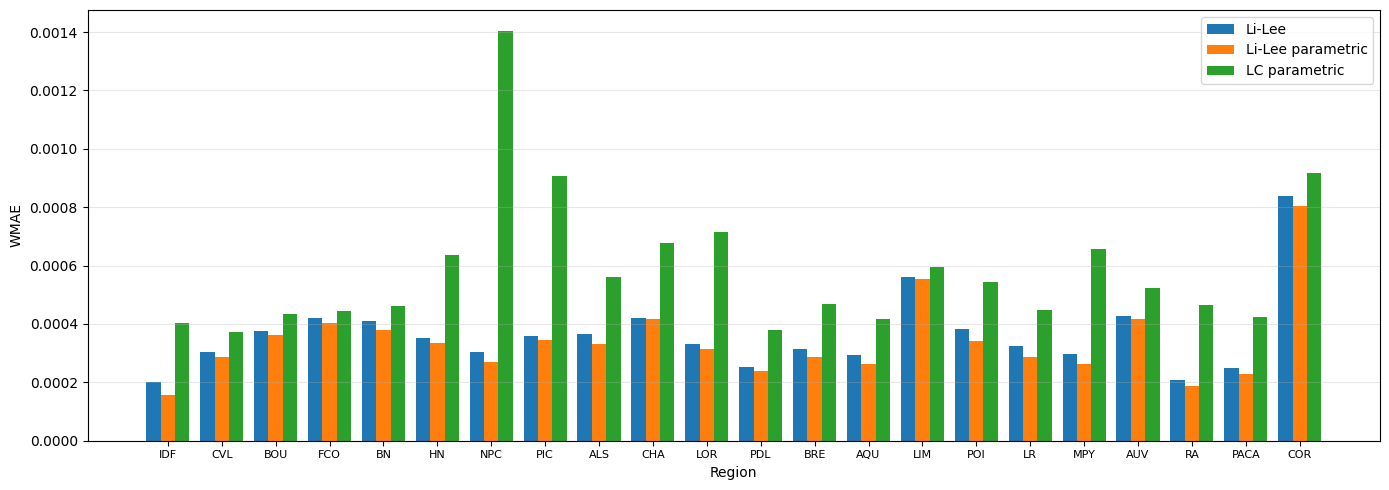

In [12]:
mpl.rc_file_defaults()

colors   = ["#1f77b4", "#ff7f0e", "#2ca02c"]
n        = len(region_labels)
n_models = len(mae)
width    = 0.8 / n_models
x        = np.arange(n)

fig, ax = plt.subplots(figsize=(14, 5))

for i, (model_name, color) in enumerate(zip(mae.keys(), colors)):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, mae[model_name], width, label=model_name, color=color)

ax.set_xticks(x)
ax.set_xticklabels(region_labels, rotation=0, fontsize=8)
ax.set_xlabel("Region")
ax.set_ylabel("WMAE")
ax.legend()
ax.grid(axis="y", alpha=0.3)
# plt.savefig(path_fr + "/Histogram_wmae.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

### 5.4 WMAE Map

Li and Lee parametric & LC parametric errors


c:\Users\Thomas Hames\Documents\GitHub\morta_nuts2\src\morta_nuts2\graph\plot_class.py:699: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


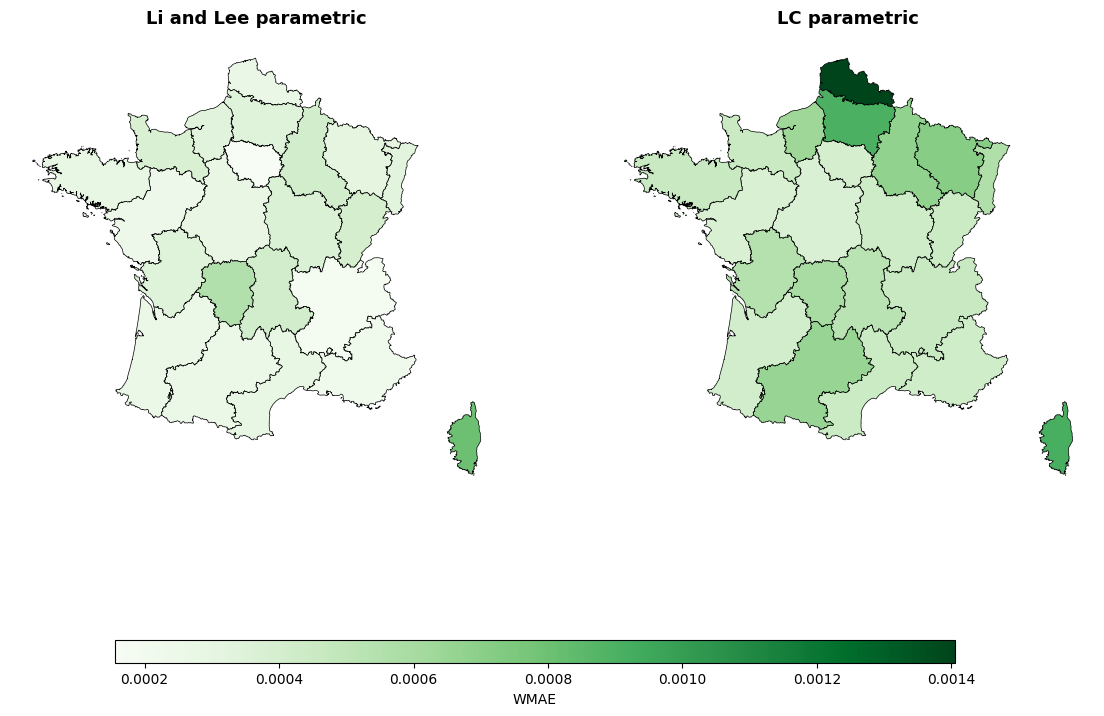

Li and Lee parametric errors


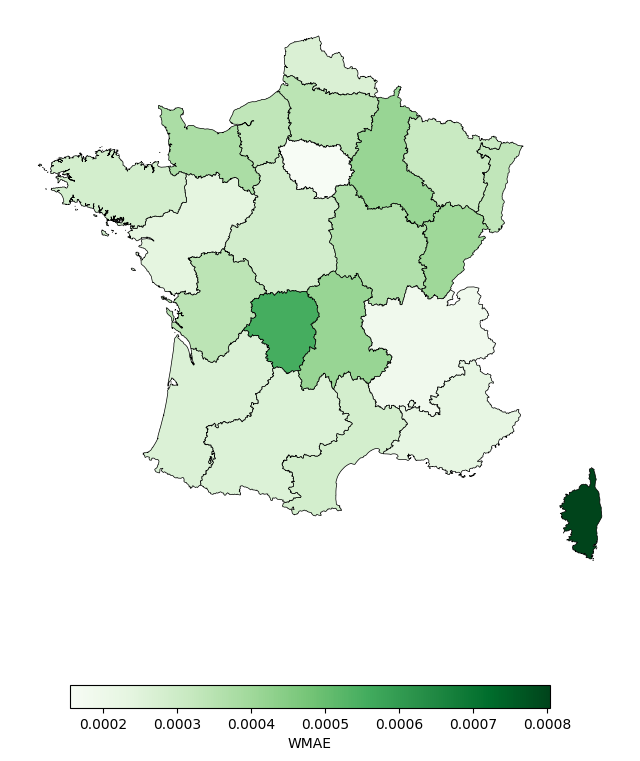

In [13]:
tv_future = np.arange(1990, 2024)
print("Li and Lee parametric & LC parametric errors")
mp = MapPlotter(regions, mae_llp['wmae_by_region'], tv_future, "FR", "WMAE", cmap="Greens")
mp.plot_compare_models(
    other_data=mae_lcp['wmae_by_region'],
    model_labels=("Li and Lee parametric", "LC parametric"),
    static=True,
    cmap_diverging="Greens",
)
print("Li and Lee parametric errors")
mp.plot_static(mae_llp['wmae_by_region'])

### 5.5 Regional Beta Curves

C:\Users\Thomas Hames\AppData\Local\Temp\ipykernel_34924\631901540.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab20", n_regions)


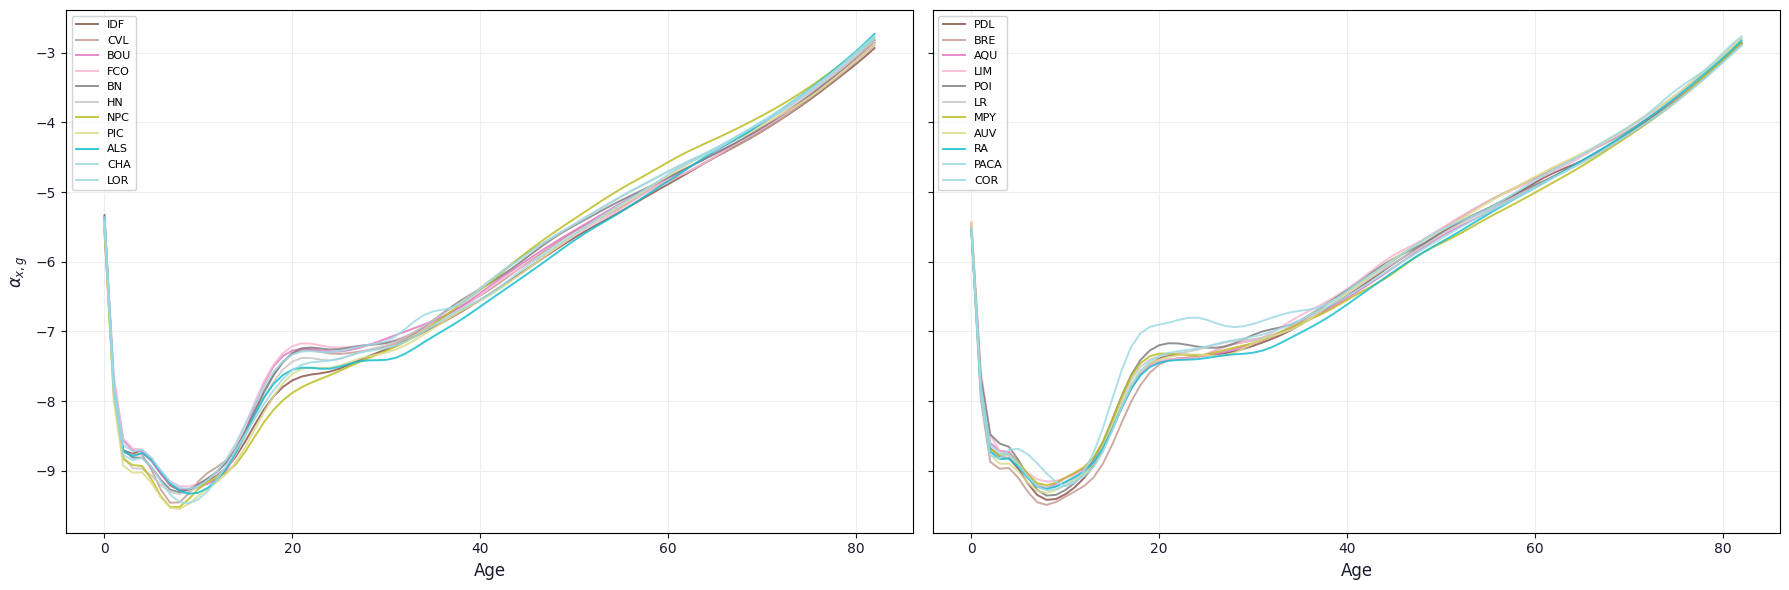

In [14]:
CURVE_KEY   = "beta_xg"
COMPARE_KEY = None
STYLE       = "white"


def plot_regional_curves(
    xv,
    curves,
    region_labels,
    compare_curve=None,
    compare_label="Reference",
    curve_key=r"$\beta_{x,g}$",
    title_prefix="Regional curves",
    style="white",
):
    """Plot B-spline regional curves (alpha or beta) split across two panels."""
    plt.rcdefaults()
    plt.style.use("default")

    n_regions = len(region_labels)
    mid       = n_regions // 2
    splits    = [
        (region_labels[:mid], curves[:, :mid], "1 / 2"),
        (region_labels[mid:], curves[:, mid:], "2 / 2"),
    ]
    palette = cm.get_cmap("tab20", n_regions)
    colors  = [palette(i) for i in range(n_regions)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True, facecolor="white")
    fig.subplots_adjust(wspace=0.08)
    fig.patch.set_facecolor("white")
    txt_color = "#1a1a2e"

    for ax, (labels, sub_curves, subtitle) in zip(axes, splits):
        start_idx = 0 if labels is region_labels[:mid] else mid
        ax.set_facecolor("white")

        for j, region in enumerate(labels):
            ax.plot(xv, sub_curves[:, j], color=colors[start_idx + j],
                    linewidth=1.4, alpha=0.85, label=region)

        if compare_curve is not None:
            ax.plot(xv, compare_curve, color="#E63946", linewidth=2.2,
                    linestyle="--", alpha=0.95, label=compare_label, zorder=10)

        ax.set_xlabel("Age", color=txt_color, fontsize=12)
        #ax.set_title(f"{title_prefix} — {subtitle}", color=txt_color, fontsize=13, pad=10)
        ax.tick_params(colors=txt_color)
        ax.grid(True, color="#EEEEEE", linewidth=0.8)
        ax.legend(fontsize=8, framealpha=0.85, loc="upper left")

    axes[0].set_ylabel(curve_key, color=txt_color, fontsize=12)
    #fig.suptitle(title_prefix, fontsize=16, fontweight="bold", color=txt_color, y=1.02)
    plt.tight_layout()
    plt.show()


plot_regional_curves(
    xv            = xv,
    curves        = result_llp["curves"]["alpha_xg"],
    region_labels = region_labels,
    compare_curve = None,
    compare_label = "LC parametric",
    curve_key     = r"$\alpha_{x,g}$",
    title_prefix  = "Regional alpha curves — Li-Lee parametric",
    style         = STYLE,
)

### 5.6 Fitted Mortality Curves

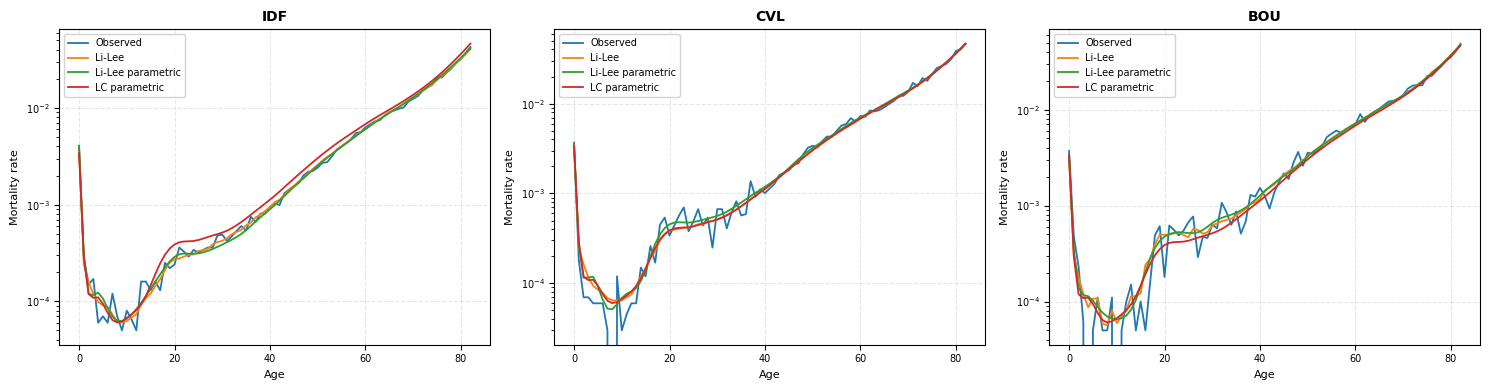

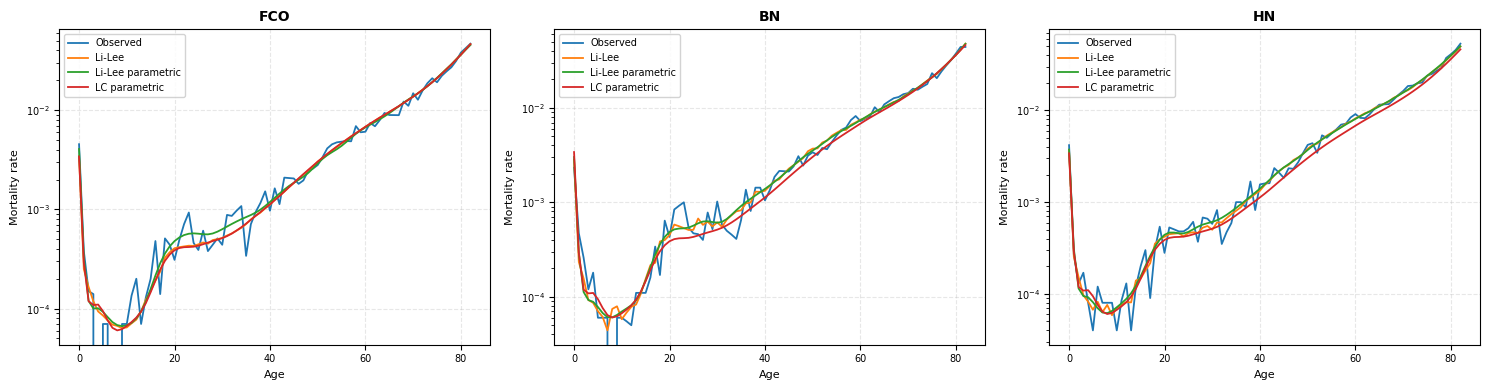

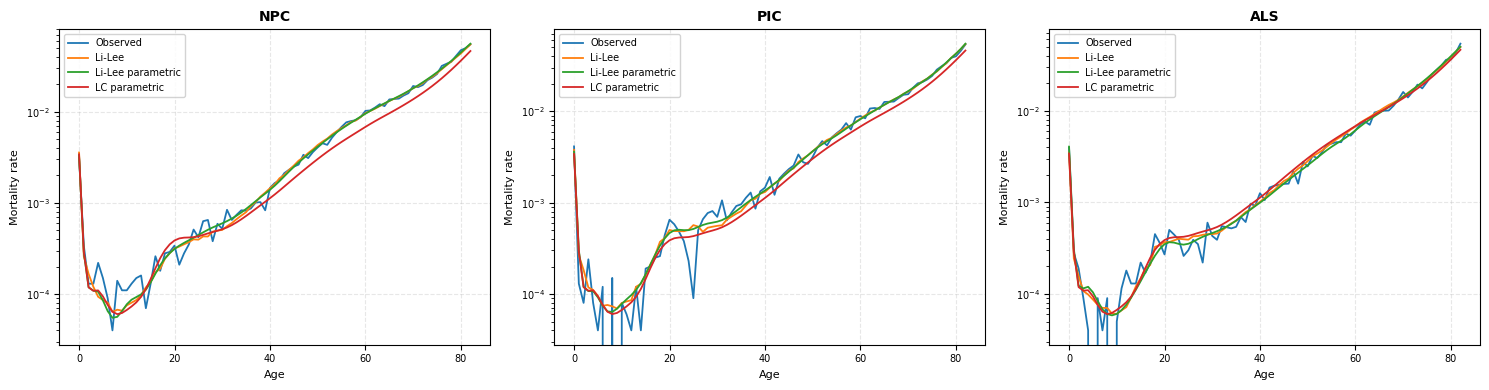

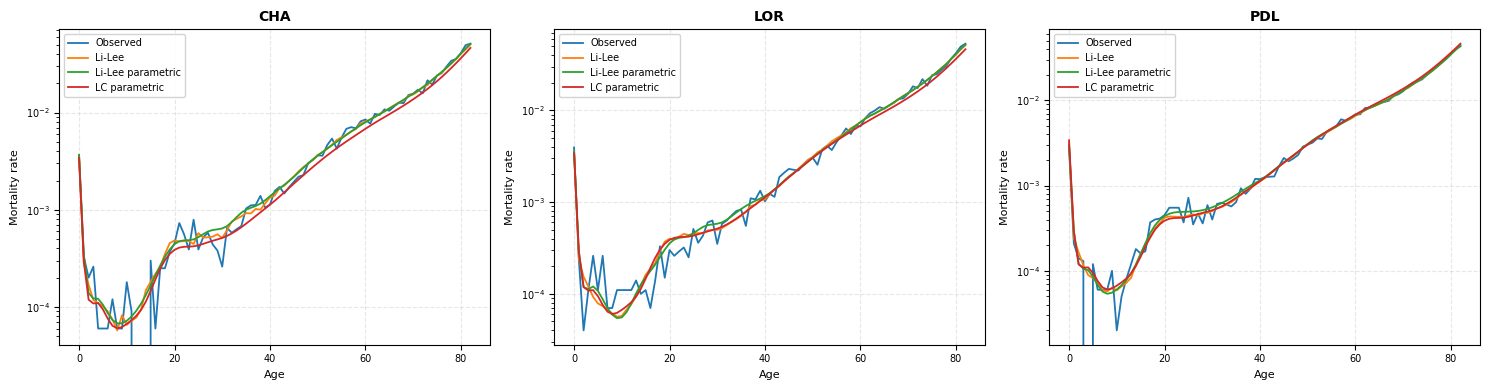

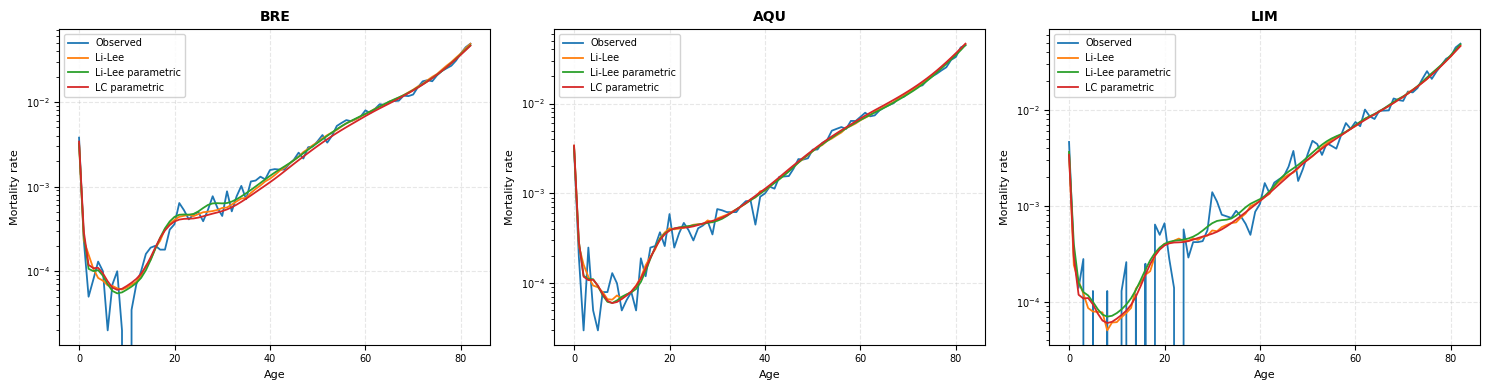

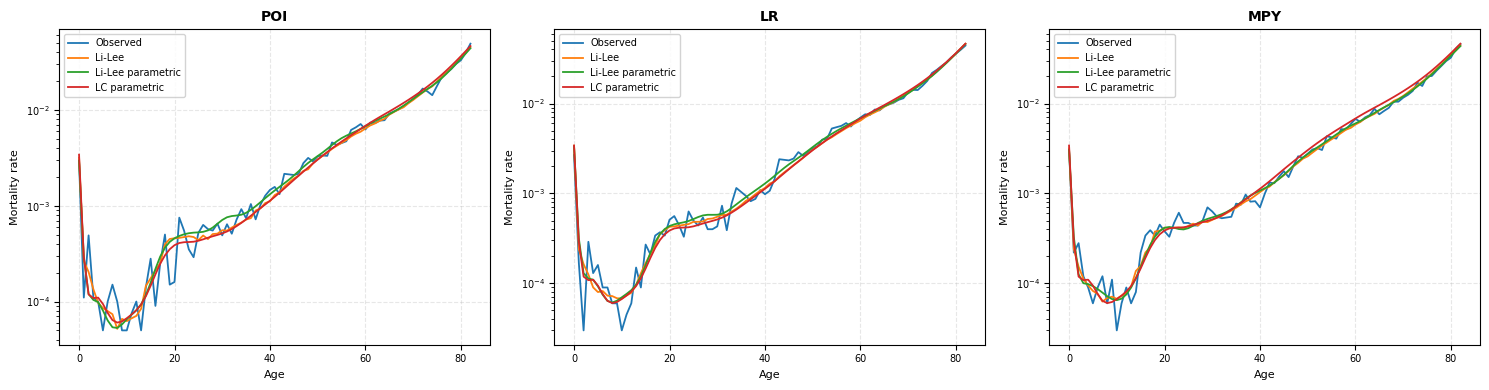

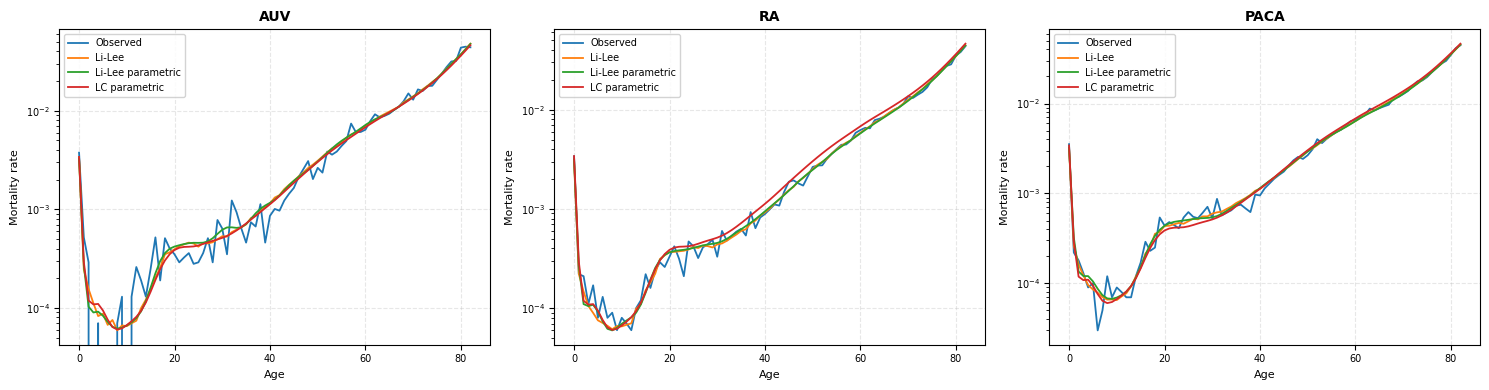

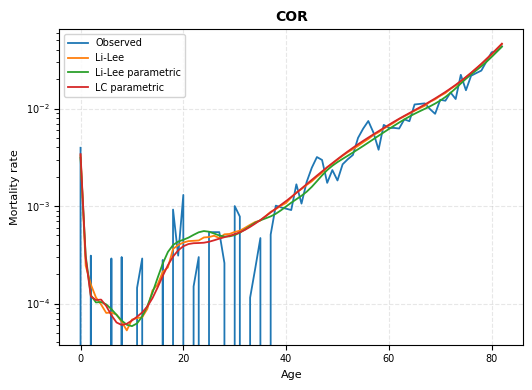

In [15]:
mu_obs     = Dxtg / Extg
mu_nat_rep = np.repeat(results_lcp_nat["fitted_values"]["mu"][:, :, None], len(regions), axis=2)

curves_fit = {
    "Observed":          mu_obs,
    "Li-Lee":            result_ll['fitted_values']['mu'],
    "Li-Lee parametric": result_llp["fitted_values"]["mu"],
    "LC parametric":     mu_nat_rep,
}

plotter = RegionalCurvePlotter(
    x_values=xv,
    curves_dict=curves_fit,
    tv=tv,
    regions=region_labels,
)
plotter.plot(year_to_plot=2015)

## 6. Stochastic Projection

In [16]:
# Projection settings
n_sim       = 2000
horizon     = 50
covid_years = ['2019', '2020', '2021']  # excluded from drift estimation

# Lee-Carter parametric
proj_lcp_stoch = ProjectorLC(
    results_lcp_nat, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=True,
    n_sim=n_sim,
    nb_components=2,
).project()

# Li-Lee parametric
proj_llp_stoch = ProjectorLL(
    result_llp, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=True,
    n_sim=n_sim,
    nb_components=2,
).project()

# Li-Lee classic
proj_ll_stoch = ProjectorLL(
    result_ll, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=True,
    n_sim=n_sim,
    nb_components=2,
).project()

### 6.1 Regional kappa_g Trajectories

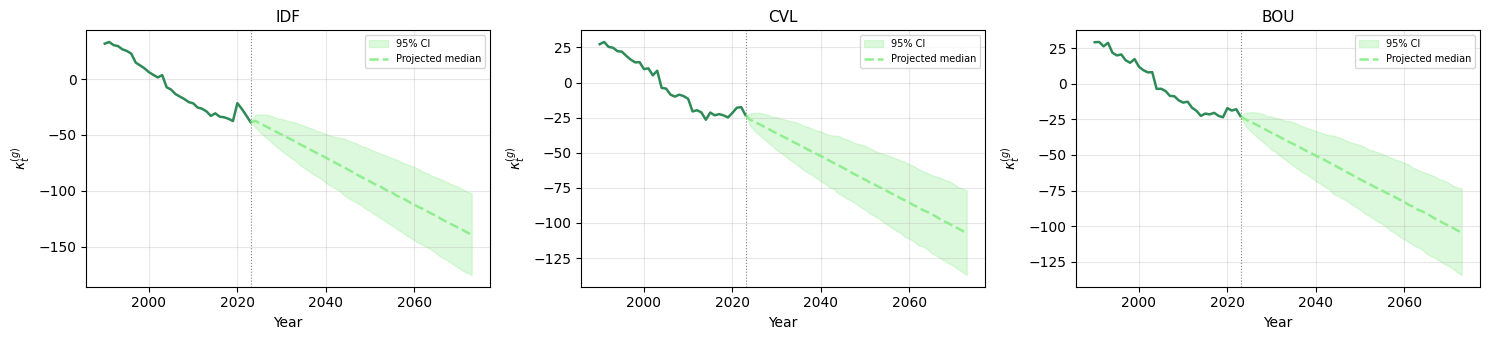

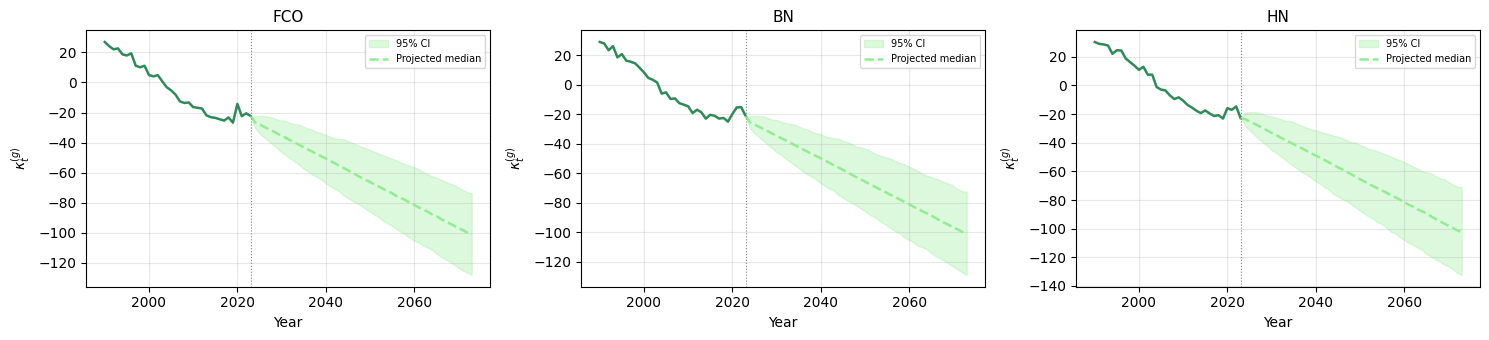

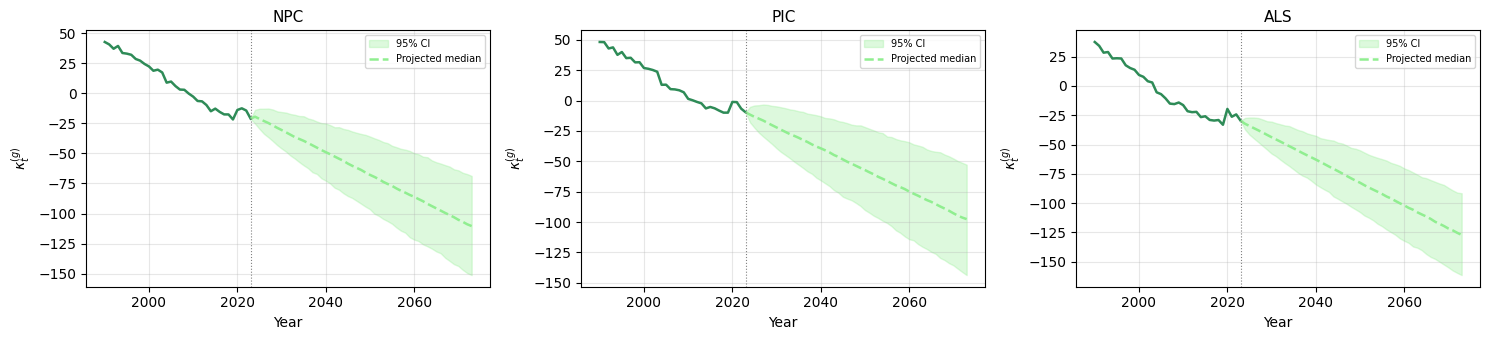

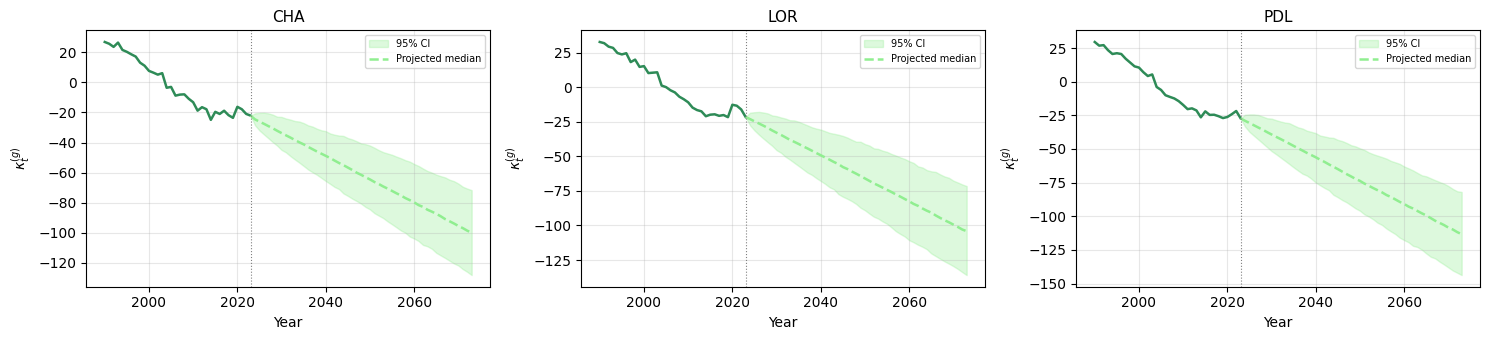

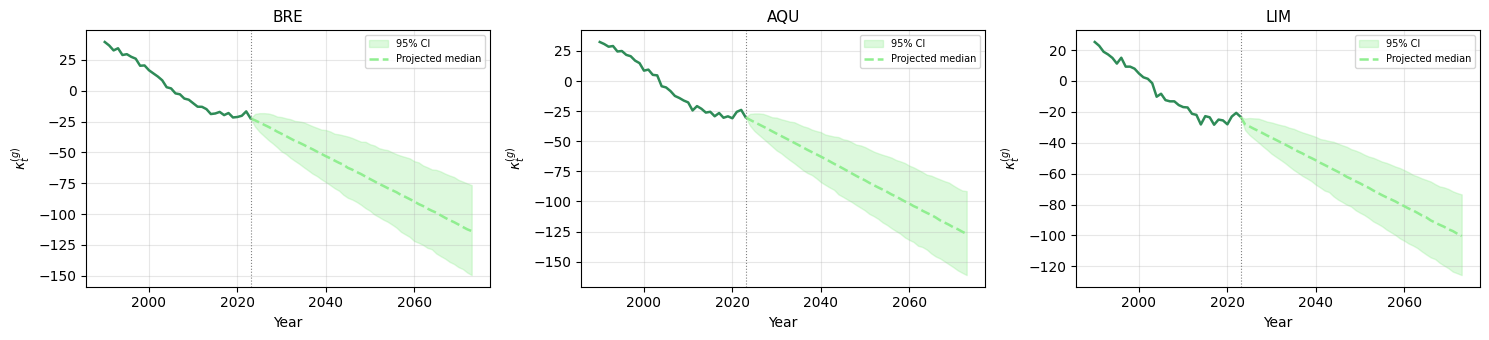

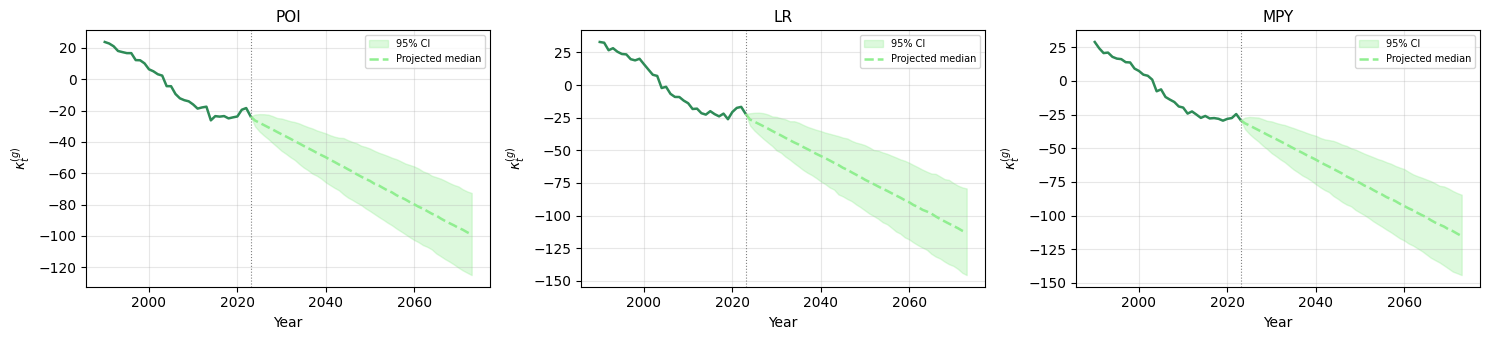

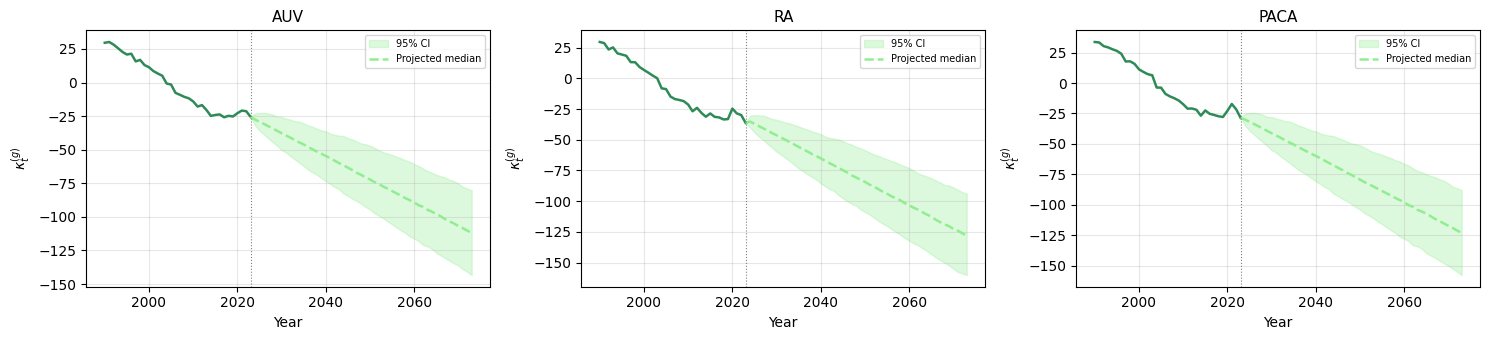

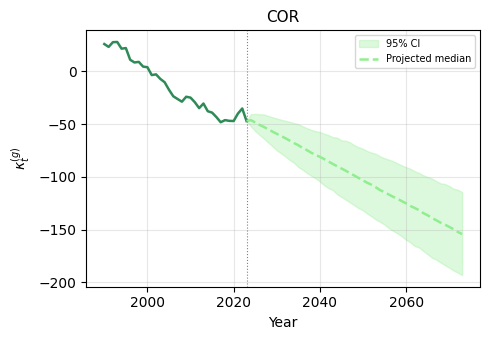

In [17]:
plt.rcParams["axes.facecolor"]    = "white"
plt.rcParams["figure.facecolor"]  = "white"
plt.rcParams["savefig.facecolor"] = "white"

COLOR_HIST = "#2e8b57"  # dark green — historical
COLOR_PROJ = "#90ee90"  # light green — projected


def plot_kappa_g(
    kappa_g_hist: np.ndarray,
    tv: np.ndarray,
    projection: dict,
    horizon: int,
    stochastic: bool = True,
    region_names: list = None,
    exclude_years: list = None,
    regions_per_fig: int = 3,
    save_path: str = None,
    dpi: int = 150,
):
    """
    Plot historical and projected kappa_g trajectories by region.
    Stochastic mode shows the median + 95% CI; deterministic shows a single path.
    Generates one figure per group of `regions_per_fig` regions.
    """
    tv            = np.asarray(tv)
    nb_regions    = kappa_g_hist.shape[0]
    tv_proj       = np.arange(tv[-1] + 1, tv[-1] + 1 + horizon)
    exclude_years = exclude_years or []
    if region_names is None:
        region_names = [f"Region {g+1}" for g in range(nb_regions)]

    n_figs = int(np.ceil(nb_regions / regions_per_fig))
    figs   = []

    for f in range(n_figs):
        g_start = f * regions_per_fig
        g_end   = min(g_start + regions_per_fig, nb_regions)
        group   = list(range(g_start, g_end))

        fig, axes = plt.subplots(1, len(group), figsize=(5 * len(group), 3.5), sharey=False)
        axes = np.array(axes).reshape(-1)

        for pos, g in enumerate(group):
            ax   = axes[pos]
            hist = kappa_g_hist[g, :]

            mask_excl = np.isin(tv, exclude_years)
            ax.plot(tv[~mask_excl], hist[~mask_excl], color=COLOR_HIST, lw=1.8)
            if mask_excl.any():
                ax.plot(tv[mask_excl], hist[mask_excl], color=COLOR_HIST, lw=1.2,
                        linestyle="--", alpha=0.45, label="Excluded years")

            last_val   = hist[-1]
            tv_bridge  = np.concatenate([[tv[-1]], tv_proj])

            if stochastic:
                med_bridge = np.concatenate([[last_val], projection["kappa_g_median"][:, g]])
                lo_bridge  = np.concatenate([[last_val], projection["kappa_g_lower"][:, g]])
                hi_bridge  = np.concatenate([[last_val], projection["kappa_g_upper"][:, g]])
                ax.fill_between(tv_bridge, lo_bridge, hi_bridge,
                                color=COLOR_PROJ, alpha=0.3, label="95% CI")
                ax.plot(tv_bridge, med_bridge, color=COLOR_PROJ, lw=1.8,
                        linestyle="--", label="Projected median")
            else:
                fut_bridge = np.concatenate([[last_val], projection["kappa_g_future"][:, g]])
                ax.plot(tv_bridge, fut_bridge, color=COLOR_PROJ, lw=1.8,
                        linestyle="--", label="Projection")

            ax.axvline(tv[-1], color="grey", lw=0.8, linestyle=":")
            ax.set_title(region_names[g], fontsize=11)
            ax.set_xlabel("Year")
            ax.set_ylabel(r"$\kappa_t^{(g)}$")
            ax.legend(fontsize=7, loc="best")
            ax.grid(True, alpha=0.3)

        fig.tight_layout()
        figs.append(fig)

        if save_path is not None:
            p   = Path(save_path)
            p.parent.mkdir(parents=True, exist_ok=True)
            out = p.parent / f"{p.stem}_part{f + 1}{p.suffix}"
            fig.savefig(out, dpi=dpi, bbox_inches="tight")
            print(f"Saved → {out}")

    plt.show()
    return figs


fig = plot_kappa_g(
    kappa_g_hist  = result_llp["parameters"]["kappa_g"],
    tv            = tv,
    projection    = proj_llp_stoch,
    horizon       = horizon,
    stochastic    = True,
    region_names  = region_labels,
    exclude_years = [],
    save_path     = None #path_fr + "/kappa_by_region_stochastic_project.png",
)

## 7. High-Age Extrapolation (up to age 110)

In [18]:
start_age = 60  # start of log-linear regression window

# LC parametric — projected simulations
logmu_nation_lcp, xv_full = HighAgeExtrapolator(
    xv             = xv,
    x_extrap       = 110,
    x_extrap_start = start_age,
    method         = "linear",
    log_Muxtg      = proj_lcp_stoch['logmu_sim'],
    auto_start     = False,
).extrapolate()

# Li-Lee parametric — projected simulations
logmu_extrap_llp, _ = HighAgeExtrapolator(
    xv             = xv,
    x_extrap       = 110,
    x_extrap_start = start_age,
    method         = "linear",
    log_Muxtg      = proj_llp_stoch["logmu_sim"],
    auto_start     = False,
).extrapolate()

# Li-Lee classic — projected simulations
logmu_extrap_ll, _ = HighAgeExtrapolator(
    xv             = xv,
    x_extrap       = 110,
    x_extrap_start = start_age,
    method         = "linear",
    log_Muxtg      = proj_ll_stoch["logmu_sim"],
    auto_start     = False,
).extrapolate()

# Li-Lee parametric — historical fitted values
logmu_llp_hist, _ = HighAgeExtrapolator(
    xv             = xv,
    x_extrap       = 110,
    x_extrap_start = start_age,
    method         = "linear",
    log_Muxtg      = result_llp["fitted_values"]["log_mu"],
    auto_start     = False,
).extrapolate()

# Li-Lee classic — historical fitted values
logmu_ll_hist, _ = HighAgeExtrapolator(
    xv             = xv,
    x_extrap       = 110,
    x_extrap_start = start_age,
    method         = "linear",
    log_Muxtg      = result_ll["fitted_values"]["log_mu"],
    auto_start     = False,
).extrapolate()


In [19]:
# # Concatenate historical + projected
# logmu_full_llp = concat_logmu_time(logmu_llp_hist, logmu_extrap_llp)
# logmu_full_ll  = concat_logmu_time(logmu_ll_hist,  logmu_extrap_ll)

# print("logmu_full_llp shape:", logmu_full_llp.shape)
# print("logmu_full_ll  shape:", logmu_full_ll.shape)
# print("Age grid       :", xv_full[0], "→", xv_full[-1])

## 8. Annuity Pricing

In [20]:
xe = np.array([60])   # subscription age
DURATION = 20
RATE     = 0.02       # discount rate

# LC parametric — national reference
price_national = Annuity_pricing(
    xe        = xe,
    xv        = xv,
    log_Muxtg = logmu_nation_lcp,
    duration  = DURATION,
    rate      = RATE,
)
print("price_national shape:", price_national.shape)  # (1, 1, n_sim)

# Li-Lee parametric — regional
price_multi = Annuity_pricing(
    xe        = xe,
    xv        = xv,
    log_Muxtg = logmu_extrap_llp,
    duration  = DURATION,
    rate      = RATE,
)
print("price_multi shape:", price_multi.shape)  # (1, nb_regions, n_sim)

price_national shape: (1, 1, 2000)
price_multi shape: (1, 22, 2000)


### 8.1 Box Plots

Regional distribution only


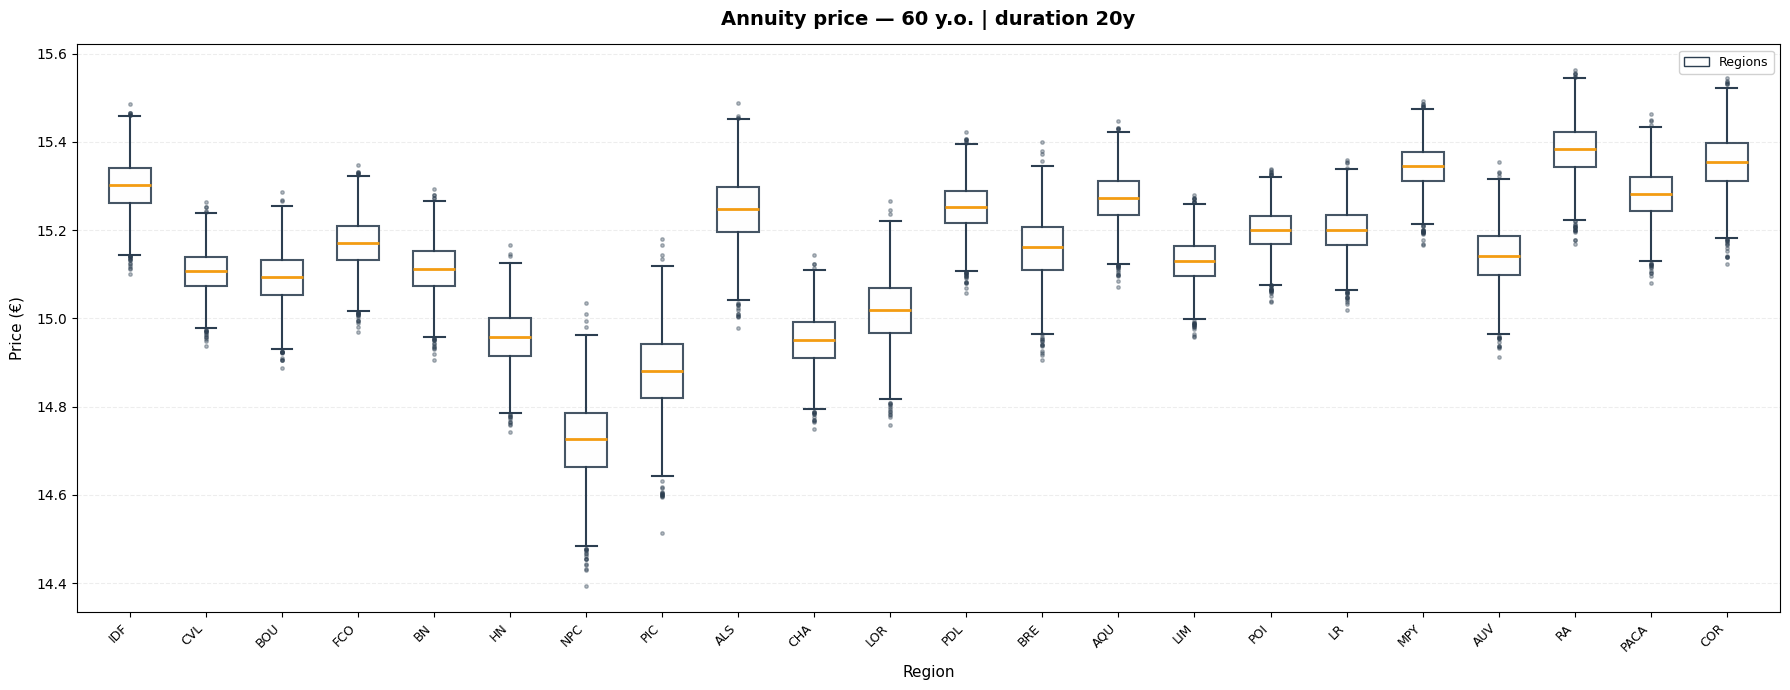

Regional + LC parametric as reference


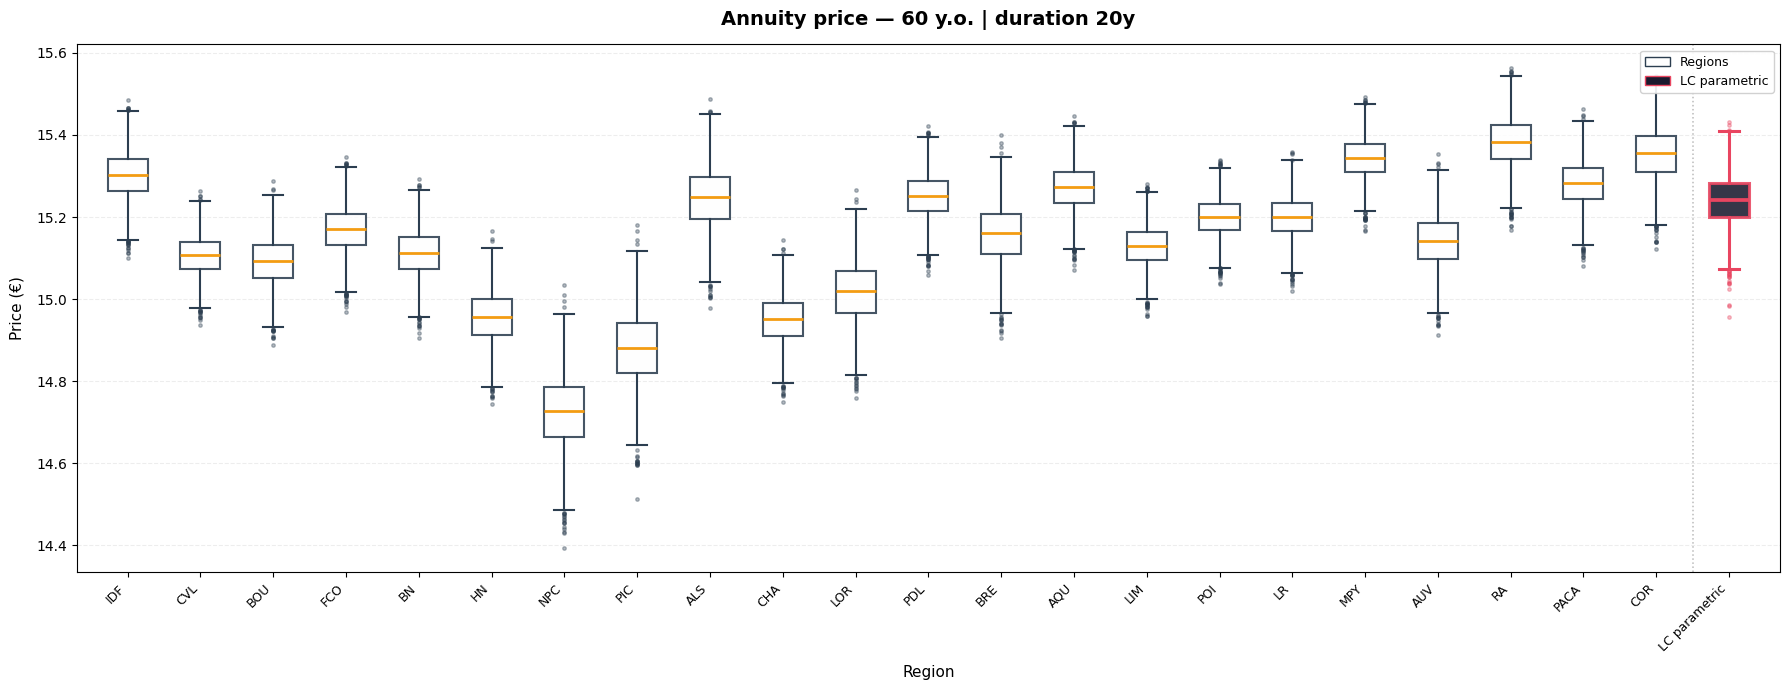

(<Figure size 1800x700 with 1 Axes>,
 <Axes: title={'center': 'Annuity price — 60 y.o. | duration 20y'}, xlabel='Region', ylabel='Price (€)'>)

In [21]:
# Regional distribution only
print("Regional distribution only")
cas1 = AnnuityBoxPlotter(price_multi, region_labels)
cas1.plot()
# cas1.save(path_fr + "/annuity.png")

# Regional + LC parametric as reference
print("Regional + LC parametric as reference")
cas2 = AnnuityBoxPlotter(price_multi, region_labels, extra_series=[
    ExtraSeries(price_national, "LC parametric", position="last"),
])
cas2.plot()
# cas2.save(path_fr + "/annuity_compare_llp_with_lcp.png")

### 8.2 Export Simulation Table

In [22]:
price_by_region = price_multi[0]   # shape: (nb_regions, n_sim)

df_price = pd.DataFrame(
    price_by_region.T,              # shape: (n_sim, nb_regions)
    columns=region_labels,
)
df_price["LC parametric"] = price_national[0, 0, :]  # scalar per simulation

df_price.index = range(1, n_sim + 1)
df_price.index.name = "simulation"
df_price = df_price.reset_index()
df_price = df_price.round(2)
# df_price.to_csv(path_fr + "/annuity_table.csv", index=False)
df_price.head()

,simulation,IDF,CVL,BOU,FCO,BN,HN,NPC,PIC,ALS,...,AQU,LIM,POI,LR,MPY,AUV,RA,PACA,COR,LC parametric
0,1,15.29,15.11,15.10,15.17,15.12,14.97,14.75,14.92,15.24,...,15.28,15.13,15.20,15.21,15.34,15.14,15.37,15.29,15.33,15.21
1,2,15.38,15.17,15.16,15.24,15.18,15.02,14.78,14.90,15.34,...,15.34,15.20,15.26,15.25,15.41,15.22,15.47,15.35,15.46,15.37
2,3,15.32,15.12,15.11,15.19,15.13,14.97,14.73,14.87,15.27,...,15.29,15.16,15.22,15.22,15.37,15.16,15.41,15.30,15.39,15.14
3,4,15.24,15.06,15.05,15.11,15.06,14.91,14.70,14.89,15.18,...,15.22,15.07,15.15,15.17,15.29,15.09,15.31,15.24,15.26,15.17
4,5,15.32,15.11,15.09,15.18,15.11,14.94,14.66,14.78,15.25,...,15.28,15.15,15.21,15.19,15.36,15.14,15.41,15.28,15.40,15.17
